# Exercises in linear regression

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

energy_efficiency_file_path = './EnergyEfficiency.csv'
energy_data = pd.read_csv(energy_efficiency_file_path)
energy_data

,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,HeatingLoad,CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


## Exercise 1

Load in the "EnergyEfficiency.csv" data (on Moodle). It is data about energy efficiency of buildings, more specifically it is about predicting the heating load and cooling load of building based on a set of features about the buildings. It is retrieved from UCI Machine Learning Repository: [Energy efficiency](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

Answer the following questions:

1. Do a visualization of the relationship/correlation between the variables `SurfaceArea` and `HeatingLoad`, with `HeatingLoad` as the dependent variable (y variable).

-0.6581202267776216
             SurfaceArea  HeatingLoad
SurfaceArea      1.00000     -0.65812
HeatingLoad     -0.65812      1.00000


Text(0.5, 1.0, 'Visualization of correlation between SurfaceArea and HeatingLoad')

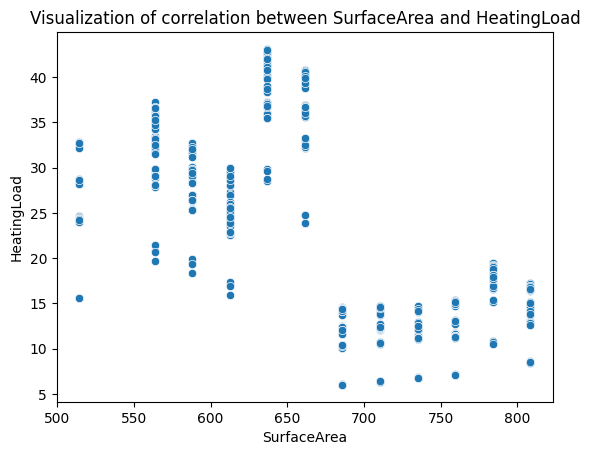

In [15]:
# Numbers
correlation = energy_data['SurfaceArea'].corr(energy_data['HeatingLoad'])
print(correlation)

correlation = energy_data[['SurfaceArea', 'HeatingLoad']].corr()
print(correlation)

# Visual
sns.scatterplot(x='SurfaceArea', y='HeatingLoad', data=energy_data)
plt.title('Visualization of correlation between SurfaceArea and HeatingLoad')

2. Is there a correlation between `SurfaceArea` and `HeatingLoad`? If so, what is the strength of it, and is it statistically significant? Does this make sense to you, if `SurfaceArea` is the surface area of a building and the `HeatingLoad` is how much energy it takes to heat up the building?

We have a correlation coefficient on -0.6581. There is a negative correlation between `SurfaceArea` and `HeatingLoad`. This is a moderate negative correlation, with with just this information is abit counterintuitive.

3. Add `hue = "OverallHeight"` to the scatterplot you did as an answer to question 1. Assuming that `OeverallHeight` represent the height of the building, does it change your answer to the last question of 2?

When you look at it, with the buildings separated in height the correlations makes more sense. From the graf you can see both have a posetive correlation, which makes more sense. The overall negative correlation happened earlier because taller buildings (which need more heating) tend to have smaller surface areas relative to their volume.

Text(0.5, 1.0, 'Visualization of correlation between SurfaceArea and HeatingLoad (with hue)')

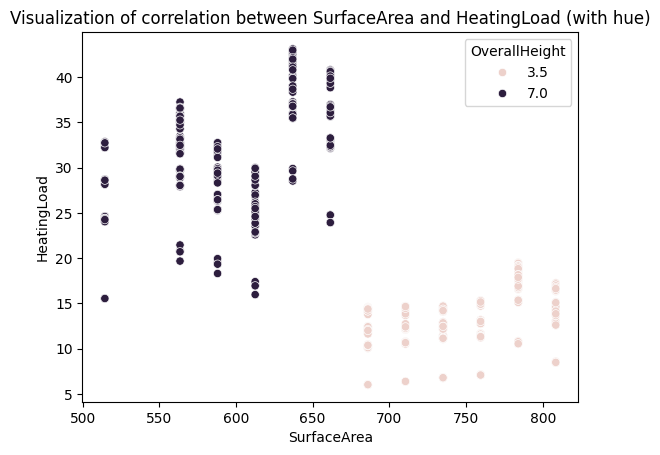

In [23]:
sns.scatterplot(x='SurfaceArea', y='HeatingLoad', data=energy_data, hue='OverallHeight')
plt.title('Visualization of correlation between SurfaceArea and HeatingLoad (with hue)')

4. Train a simple linear regression model with `SurfaceArea` as independent variable (x) and `HeatingLoad` as dependent variable (y).

In [24]:
X = energy_data['SurfaceArea']
X = sm.add_constant(X)

y = energy_data['HeatingLoad']

linreg_model = sm.OLS(y, X).fit()
linreg_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            HeatingLoad   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     585.3
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.69e-96
Time:                        16:29:28   Log-Likelihood:                -2646.6
No. Observations:                 768   AIC:                             5297.
Df Residuals:                     766   BIC:                             5306.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          72.9454      2.111     34.554      0.000      68.801      77.090
SurfaceArea    -0.0754      0.003    -24.192      0.000      -0.082      -0.069
==============================================================================
Omnibus:                       37.973   Durbin-Watson:                   0.321
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               42.851
Skew:                           0.576   Prob(JB):                     4.95e-10
Kurtosis:                       2.890   Cond. No.                     5.21e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.21e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

5. What does the model say about the change in `HeatingLoad` when the `SurfaceArea` goes up by 1 unit?

In [28]:
coefficient = linreg_model.params['SurfaceArea']
print(f"When SurfaceArea increases by 1 unit, HeatingLoad changes by: {coefficient}")

When SurfaceArea increases by 1 unit, HeatingLoad changes by: -0.07538715748537175


6. Add the linear regression line to a scatterplot of `SurfaceArea` and `HeatingLoad`.

Text(0.5, 1.0, 'Linear regression plot for SurfaceArea and HeatingLoad')

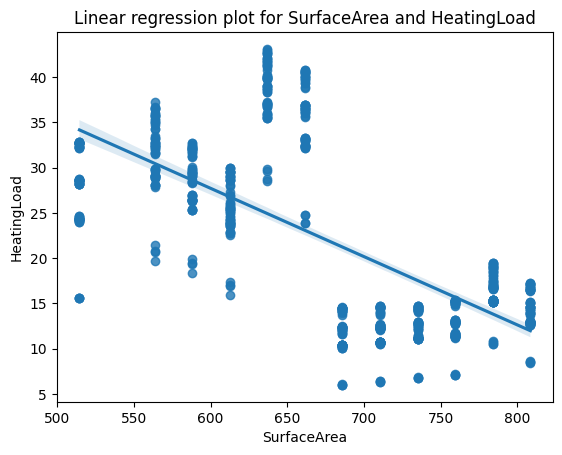

In [18]:
sns.regplot(x='SurfaceArea', y='HeatingLoad', data=energy_data)
plt.title('Linear regression plot for SurfaceArea and HeatingLoad')

7. Evaluate how good your simple linear regression model is. Hint: Chose one or several measures to evaluate your model.

8. Subset your data such that you only have houses with "OverallHeight=7" and train a new simple linear regression model with `SurfaceArea` as independent variable and `HeatingLoad` as dependent variable. How good is this model compared to the on trained on the full dataset?

In [42]:
subset_data = energy_data[energy_data['OverallHeight'] == 7]

X = subset_data['SurfaceArea']
X = sm.add_constant(X)

y = subset_data['HeatingLoad']

linreg_model = sm.OLS(y, X).fit()
linreg_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            HeatingLoad   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     104.8
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           6.84e-22
Time:                        16:49:50   Log-Likelihood:                -1183.0
No. Observations:                 384   AIC:                             2370.
Df Residuals:                     382   BIC:                             2378.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -2.7676      3.337     -0.829      0.407      -9.328       3.793
SurfaceArea     0.0571      0.006     10.236      0.000       0.046       0.068
==============================================================================
Omnibus:                       15.054   Durbin-Watson:                   0.315
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               15.752
Skew:                          -0.474   Prob(JB):                     0.000380
Kurtosis:                       2.706   Cond. No.                     7.40e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.4e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Exercise 2

In this exercise, we will continue from Exercise 1 and keep using the "EnergyEfficiency.csv" data (on Moodle).

Answer the following questions:
1. Train a multiple linear regression model for `HeatingLoad` using at least two other variables from the dataset as feature variables.
2. Evaluate our multiple linear regression model and compare its performance to your simple linear regression model. Did you manage to make a better model?

In [20]:
# 1. Train a multiple linear regression model for `HeatingLoad` using at least two other variables from the dataset as feature variables.


In [21]:
# 2. Evaluate our multiple linear regression model and compare its performance to your simple linear regression model. Did you manage to make a better model?

## Exercise 3

In this exercise, we will use the Ames dataset from the multiple linear regression notebook.

Answer the following questions:
1. Can you train a linear regression model to achieve a lower RMSE than the models we saw in the multiple linear regression notebook?
2. Can you train a linear regression model to achieve a higher R-squared than the final model in the multiple linear regression notebook?
3. Do your models satisfy the assumptions of linear regression?